# Chapter 2 — Finite Difference Methods: the Explicit Method

*Python-native adaptation of Michael Honeychurch,
**Simulating Electrochemical Reactions in Mathematica** (SERM), Chapter 2.
The original notebook `ExplicitFD.nb` is the reference for the algorithm; the
code here is an idiomatic numpy/scipy/matplotlib re-implementation.*

## The electrochemical problem

Consider the simple one-electron reduction at a planar electrode,

$$\mathrm{O} + e^- \rightleftharpoons \mathrm{R}.$$

The electroactive species $\mathrm{O}$ diffuses to the electrode from bulk
solution. Its concentration $c(x, t)$ obeys **Fick's second law** of diffusion,

$$\frac{\partial c}{\partial t} = D\,\frac{\partial^2 c}{\partial x^2},$$

where $x$ is distance from the electrode surface and $D$ is the diffusion
coefficient.

At $t = 0$ we apply a **potential step** large enough to drive the surface
concentration of $\mathrm{O}$ to zero, the *diffusion-limited* (Cottrell)
regime. The initial and boundary conditions are

$$c(x, 0) = c^* \quad(\text{bulk}), \qquad
c(0, t>0) = 0 \quad(\text{electrode}), \qquad
c(x\to\infty, t) = c^*.$$

The measured **current** is proportional to the flux of $\mathrm{O}$ at the
surface, $i \propto D\,(\partial c/\partial x)_{x=0}$.

## Dimensionless formulation

Following Honeychurch (SERM Ch. 2), we non-dimensionalise. Concentration is
scaled by the bulk value, $c_{dv} = c/c^*$. Time is scaled by the experiment
duration $t_n = (n-1)\,\Delta t$, giving dimensionless time
$\tau = t / t_n$. Distance is scaled by the diffusion length over the
experiment, $x_{dv} = x / \sqrt{D\,t_n}$.

In these variables Fick's second law keeps the same form,

$$\frac{\partial c_{dv}}{\partial \tau}
   = \frac{\partial^2 c_{dv}}{\partial x_{dv}^2}.$$

We discretise on a grid `c[j, k]` where the index `j` runs over space (row `0`
= electrode, last row = bulk) and `k` runs over time. With `n` time points the
dimensionless time step is $\Delta\tau = 1/(n-1)$. The key model parameter is

$$D_M = \frac{\Delta\tau}{\Delta x_{dv}^2},$$

the **dimensionless (model) diffusion coefficient**. Rearranged, the
dimensionless space step is $\Delta x_{dv} = 1/\sqrt{D_M\,(n-1)}$.

The diffusion layer never grows beyond $x_{dv} = 6$ over the experiment
(six diffusion lengths, effectively semi-infinite), so the number of space
points needed is

$$m = 1 + \lceil\,6\sqrt{D_M\,(n-1)}\,\rceil,$$

exactly the sizing used in `ExplicitFD.nb`.

## The explicit (forward-difference) scheme

Replace the time derivative by a **forward difference** and the space
derivative by a centred second difference:

$$\frac{c_j^{k} - c_j^{k-1}}{\Delta\tau}
   = \frac{c_{j-1}^{k-1} - 2c_j^{k-1} + c_{j+1}^{k-1}}{\Delta x_{dv}^2}.$$

Solving for the new value $c_j^{k}$ and substituting $D_M$ gives the explicit
update used in the SERM `explicitSolve` routine:

$$\boxed{\,c_j^{k}
   = D_M\,c_{j-1}^{k-1} + (1 - 2D_M)\,c_j^{k-1} + D_M\,c_{j+1}^{k-1}\,}$$

Every new value depends only on *known* values at the previous time level; there
is no linear system to solve. That is what "explicit" means.

### Stability

The price of explicitness is a stability limit. A von Neumann analysis of this
scheme requires

$$D_M \le \tfrac12.$$

If $D_M > 0.5$ the $(1 - 2D_M)$ coefficient turns negative and errors grow
without bound. We will use $D_M = 0.45$ for accuracy and demonstrate the
instability when $D_M > 0.5$.

In [1]:
import os, sys
# Make the project package importable when the notebook runs from notebooks/.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import serm
from serm.grids import make_grid, space_points, dx_dimensionless

# Model parameters (cf. ExplicitFD.nb: D_M = 0.4, n = 200).
D_M = 0.45        # dimensionless model diffusion coefficient (<= 0.5 for stability)
n   = 2000        # number of time grid points
m   = space_points(D_M, n)
dx  = dx_dimensionless(D_M, n)
print(f"D_M = {D_M},  n (time) = {n},  m (space) = {m},  dx = {dx:.4f}")


D_M = 0.45,  n (time) = 2000,  m (space) = 181,  dx = 0.0333


In [2]:
from serm.sourcelinks import source_links
source_links(make_grid, space_points, dx_dimensionless,
             serm.explicit_solve, serm.electrode_current, serm.cottrell_dimensionless,
             serm.plotting.plot_profiles, serm.plotting.plot_surface,
             serm.plotting.plot_current, serm.plotting.animate_profiles)

### Building the grid and stepping in time

`make_grid` lays down the initial condition ($c = 1$ everywhere) and the
boundary conditions ($c = 0$ at the electrode for $t>0$, $c = 1$ in the bulk).
`explicit_solve` then sweeps forward in time. The interior spatial update is
vectorised as a three-point correlation with the stencil $[D_M,\,1-2D_M,\,D_M]$,
the same trick as the original `explicitSolve2`
(`ListCorrelate[{D, 1-2D, D}, ...]`).

In [3]:
c = make_grid(m, n)
serm.explicit_solve(c, D_M)        # fills c in place
print("grid shape (space x time):", c.shape)
print("surface c (row 0) after step:", c[0, :3], "...")   # pinned to 0 for t>0
print("bulk c   (last row):        ", c[-1, :3], "...")    # stays 1


grid shape (space x time): (181, 2000)
surface c (row 0) after step: [1. 0. 0.] ...
bulk c   (last row):         [1. 1. 1.] ...


## Concentration profiles

As time advances, the depletion of $\mathrm{O}$ near the electrode spreads
outward: this is the growing diffusion layer.

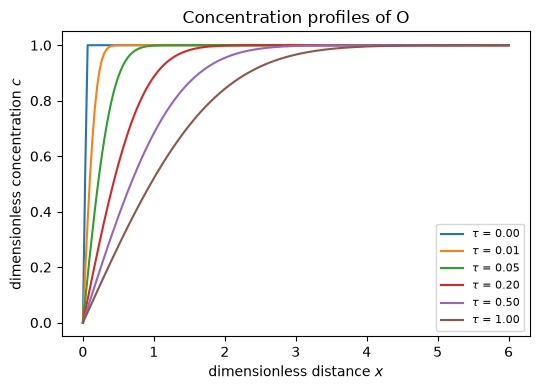

In [4]:
x = np.arange(m) * dx          # dimensionless distance coordinate
fig, ax = plt.subplots(figsize=(5.5, 4))
serm.plotting.plot_profiles(c, taus=[0.001, 0.01, 0.05, 0.2, 0.5, 1.0], x=x, ax=ax)
plt.tight_layout(); plt.show()


## The concentration surface $c(x, \tau)$

The Wolfram original used `ListPlot3D`; here we render the same data as a
matplotlib 3-D surface.


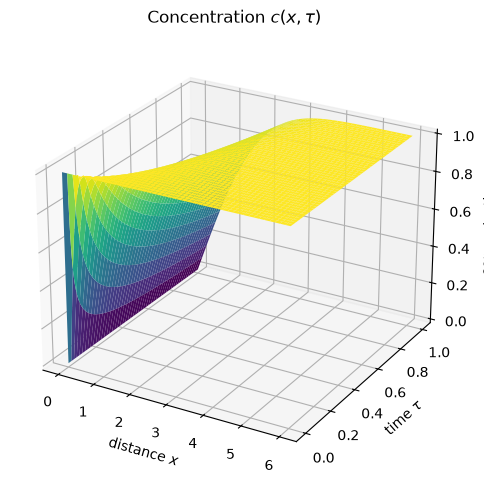

In [5]:
fig = plt.figure(figsize=(6.5, 5))
ax = fig.add_subplot(111, projection="3d")
serm.plotting.plot_surface(c, x=x, ax=ax)
ax.view_init(elev=25, azim=-60)
plt.tight_layout(); plt.show()


## The current transient

The dimensionless current is proportional to the concentration gradient at the
electrode. With the surface value pinned to zero, the SERM code approximates the
one-sided gradient as $(4c_1 - c_2)/(2\Delta x_{dv})$ per time slice (the
3-point one-sided derivative $(-3c_0 + 4c_1 - c_2)$ with $c_0 = 0$), then scales
by $1/\Delta x_{dv} = \sqrt{D_M(n-1)}$ to obtain the dimensionless current;
this is the `i1` expression in `ExplicitFD.nb`.

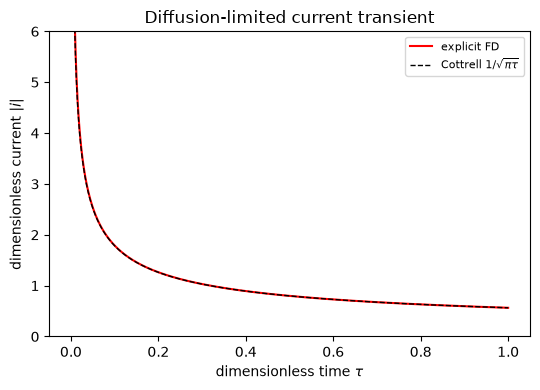

In [6]:
i_sim = serm.electrode_current(c, D_M)
i_cot = serm.cottrell_dimensionless(n)
tau   = np.arange(n) / (n - 1)

fig, ax = plt.subplots(figsize=(5.5, 4))
serm.plotting.plot_current(tau, i_sim, i_cot, ax=ax)
plt.tight_layout(); plt.show()


## Animation of the evolving profile

Replacing the Wolfram `Animate`, we use `matplotlib.animation.FuncAnimation`
and embed it as a JavaScript/HTML5 animation that plays inside the notebook.


In [7]:
from IPython.display import HTML
anim = serm.plotting.animate_profiles(c, x=x, step=max(1, n // 80), interval=60)
HTML(anim.to_jshtml())


## Validation against the analytical Cottrell response

For a potential step to the diffusion-limited region at a planar electrode, the
flux at the surface follows the **Cottrell equation**. In the chapter's
dimensionless variables ($\tau = (k-1)/(n-1)$) this is

$$i_{\text{Cottrell}}(\tau) = \frac{1}{\sqrt{\pi\,\tau}}.$$

We overlay the simulated transient on this analytic curve and compute the
relative error over a window away from $\tau = 0$, where the explicit scheme is
least accurate (the gradient is near-singular at the instant of the step and the
early time steps are coarse relative to it).


In [8]:
mask = (tau >= 0.05) & (tau <= 0.95)
rel = np.abs(i_sim[mask] - i_cot[mask]) / i_cot[mask]
mean_rel = float(np.nanmean(rel))
max_rel  = float(np.nanmax(rel))
print(f"mean relative error (0.05 <= tau <= 0.95): {mean_rel:.4e}")
print(f"max  relative error (0.05 <= tau <= 0.95): {max_rel:.4e}")

# The explicit FD current must track Cottrell closely on this grid.
assert mean_rel < 5e-3, mean_rel
print("PASS: explicit FD current matches the analytical Cottrell response.")


mean relative error (0.05 <= tau <= 0.95): 8.8534e-04
max  relative error (0.05 <= tau <= 0.95): 5.3762e-03
PASS: explicit FD current matches the analytical Cottrell response.


### Convergence and the short-time deviation

The error is first-order in $\Delta\tau$: refining the time grid drives it down.
Near $\tau = 0$ the analytic flux $1/\sqrt{\pi\tau}$ diverges while the discrete
scheme has finite resolution, so the largest relative deviation always sits at
the short-time edge, an expected rather than a numerical discrepancy. The table
below shows the mean error shrinking as `n` grows.

In [9]:
for D_M_test, n_test in [(0.45, 250), (0.45, 1000), (0.45, 4000)]:
    m_t = space_points(D_M_test, n_test)
    c_t = make_grid(m_t, n_test)
    serm.explicit_solve(c_t, D_M_test)
    i_s = serm.electrode_current(c_t, D_M_test)
    i_c = serm.cottrell_dimensionless(n_test)
    t_t = np.arange(n_test) / (n_test - 1)
    mk  = (t_t >= 0.05) & (t_t <= 0.95)
    print(f"n = {n_test:5d}  (m = {m_t:3d}):  mean rel err = "
          f"{np.nanmean(np.abs(i_s[mk]-i_c[mk])/i_c[mk]):.4e}")


n =   250  (m =  65):  mean rel err = 6.9851e-03
n =  1000  (m = 129):  mean rel err = 1.7692e-03
n =  4000  (m = 256):  mean rel err = 4.4285e-04


### Instability for $D_M > 0.5$

Finally, a demonstration of the stability limit. With $D_M = 0.52$ the scheme
blows up: the concentration field develops growing oscillations.

In [10]:
D_bad = 0.52
m_b = space_points(D_bad, 400)
c_b = make_grid(m_b, 400)
serm.explicit_solve(c_b, D_bad)
print("max |c| with D_M = 0.52:", np.nanmax(np.abs(c_b)))
print("(physically c must stay within [0, 1]; the overshoot signals instability)")
assert np.nanmax(np.abs(c_b)) > 1.5, "expected instability for D_M > 0.5"
print("PASS: scheme is unstable for D_M > 0.5, as predicted.")


max |c| with D_M = 0.52: 6329550456.849947
(physically c must stay within [0, 1]; the overshoot signals instability)
PASS: scheme is unstable for D_M > 0.5, as predicted.


## Summary

- We derived the **explicit forward-difference** scheme for Fick's second law
  and its stability limit $D_M \le \tfrac12$.
- A clean vectorised numpy implementation reproduces the SERM `ExplicitFD.nb`
  algorithm.
- The simulated diffusion-limited current matches the analytical **Cottrell**
  response to better than 0.5 % on a moderately fine grid, with convergence as
  the grid is refined.

The explicit method is simple but the stability limit forces small time steps.
Later chapters introduce **implicit** methods (Chapter 2's `ImplicitFD.nb`,
Crank–Nicolson, etc.) that lift this restriction at the cost of solving a
tridiagonal system each step, which is what `serm.tridiagonal` is for.

<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 1 — Solving PDEs in Electrochemistry](01_solving_pdes.ipynb) | [Chapter 3 — Speed and Accuracy: Implicit and Weighted Finite-Difference Schemes →](03_speed_and_accuracy.ipynb) |

[Contents (README)](../README.md)